# CMIP7 ScenarioMIP — Infographic Figure

**Two-panel A3 portrait infographic** based on Van Vuuren et al. (2026):  
- **(a)** GHG emissions pathways for six scenarios (GtCO₂eq yr⁻¹, AR6 GWP-100)  
- **(b)** Global mean temperature outcomes from a probabilistic FaIR ensemble (°C above 1850–1900)  

All data values are loaded directly from the same source files as the original analysis.  
No numbers are invented or hard-coded.

---
**Workflow:**  
1. Run **Cell 2** (imports).  
2. Edit **Cell 3** (visual config) — the only cell you need to touch for tweaks.  
3. Run **Cells 4–5** to load and pre-process data (fast).  
4. Run **Cell 6** to run the FaIR ensemble (~3–5 min, do this once per session).  
5. Run **Cell 7** to build and save the SVG.  After tweaking Cell 3, only re-run Cell 7.

In [296]:
%matplotlib inline

# ── IMPORTS ────────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from fair import FAIR
from fair.io import read_properties
from fair.interface import initialise

## ── TWEAK ME ──
All visual variables live here.  Edit this cell and re-run **Cell 7** to see changes — no need to re-run the FaIR model.

In [298]:
# ── VISUAL CONFIG ──────────────────────────────────────────────────────────────

# ── Figure geometry ────────────────────────────────────────────────────────────
FIG_WIDTH_IN  = 11.7
FIG_HEIGHT_IN = 14.0
MARGIN = dict(left=0.12, right=0.82, top=0.96, bottom=0.06, hspace=0.38)

# ── Time ranges ────────────────────────────────────────────────────────────────
YEAR_HIST_START = 2000   # start of historical squiggle
YEAR_START      = 2020
YEAR_MAIN_END   = 2100

# ── Scenario colors ────────────────────────────────────────────────────────────
SCENARIO_COLORS = {
    'high-extension':    '#800000',
    'medium-extension':  '#fc7b03',
    'medium-overshoot':  '#d3a640',
    'low':               '#098740',
    'verylow':           '#0080d0',
    'verylow-overshoot': '#100060',
}

# ── Scenario display labels ────────────────────────────────────────────────────
SCENARIO_LABELS = {
    'high-extension':    'H',
    'medium-extension':  'M',
    'medium-overshoot':  'ML',
    'low':               'L',
    'verylow':           'VL',
    'verylow-overshoot': 'LN',
}

# ── Line and band styling ──────────────────────────────────────────────────────
LINE_WIDTH  = 2.5
BAND_ALPHA  = 0.22

# ── Font sizes (pt) ────────────────────────────────────────────────────────────
FS_AXIS_LABEL  = 18
FS_XTICK       = 18
FS_YTICK       = 18
FS_LINE_LABEL  = 16

# ── Direct label placement ─────────────────────────────────────────────────────
LABEL_X_GAP = 3
LABEL_Y_OFFSETS_EMIS = {
    'high-extension':    0,
    'medium-extension':  0,
    'medium-overshoot':  0,
    'low':               0,
    'verylow':          +4,
    'verylow-overshoot': -4,
}
LABEL_Y_OFFSETS_TEMP = {
    'high-extension':    0,
    'medium-extension':  0,
    'medium-overshoot':  0,
    'low':               0,
    'verylow':          -0.13,
    'verylow-overshoot': +0.13,
}

# ── Output ─────────────────────────────────────────────────────────────────────
OUTPUT_SVG = '../plots/infographic_figure.svg'

## ── DATA LOADING & PROCESSING ──
Run once per session (or after a kernel restart).  This cell sets up FaIR and pre-processes all emissions — it takes only a few seconds.

In [300]:
# ── FaIR MODEL SETUP ──────────────────────────────────────────────────────────
# Scenario names (unchanged from original analysis)
_ALL_SNAMES = [
    'high-extension', 'high-overshoot', 'medium-extension',
    'medium-overshoot', 'low', 'verylow', 'verylow-overshoot',
]
# Figure 1 shows 6 scenarios (high-overshoot excluded, as in the paper)
NOHOS = [s for s in _ALL_SNAMES if s != 'high-overshoot']

f = FAIR()
f.define_time(1750, 2501, 1)
f.define_scenarios(_ALL_SNAMES)
species, properties = read_properties('../data/fair-parameters/species_configs_properties_1.4.1.csv')
f.define_species(species, properties)
f.ch4_method = 'Thornhill2021'
df_configs = pd.read_csv('../data/fair-parameters/calibrated_constrained_parameters_1.4.1.csv', index_col=0)
f.define_configs(df_configs.index)
f.allocate()
scens = f.emissions.scenario.values

# ── READ EMISSIONS CSV ────────────────────────────────────────────────────────
df_emis = pd.read_csv('../data/emissions/extensions_1750-2500.csv')
# AR6 GWP-100 weights for CO2e aggregation
gwpmat = df_emis.loc[df_emis.scenario == 'verylow-overshoot'].set_index('variable')['ar6_gwp_mass_adjusted']

f.fill_from_csv(
    emissions_file='../data/emissions/extensions_1750-2500.csv',
    forcing_file='../data/forcing/volcanic_solar.csv',
)

# high-extension is seeded from high-overshoot (then diverges post-2100)
f.emissions.sel(scenario='high-extension').loc[:] = f.emissions.sel(scenario='high-overshoot').copy()

# ── NON-CO2 EXTENSION DICTS ───────────────────────────────────────────────────
# Each dict maps scenario → ([breakpoint years], [values at those years]).
# np.nan as first value means "keep the historical trajectory up to that year".
ch4dict = {
    scens[0]: [[2200, 2250], [np.nan, 50]],
    scens[1]: [[2100, 2200], [np.nan, 50]],
    scens[2]: [[2300], [np.nan]],
    scens[3]: [[2040, 2050, 2060, 2125, 2150, 2300], [np.nan, 350, 300, 170, 120, 120]],
    scens[4]: [[2025, 2030, 2040, 2050, 2060, 2080, 2090, 2100, 2125, 2300],
               [np.nan, 260, 200, 150, 110, 100, 95, 95, 95, 95]],
    scens[5]: [[2025, 2030, 2040, 2050, 2060, 2080, 2090, 2100, 2125, 2300],
               [np.nan, 260, 150, 120, 100, 95, 90, 90, 90, 90]],
    scens[6]: [[2025, 2030, 2050, 2060, 2100, 2300], [np.nan, 360, 300, 170, 120, 120]],
}
n2odict = {
    scens[0]: [[2200, 2250], [np.nan, 6]],
    scens[1]: [[2100, 2200], [np.nan, 6]],
    scens[2]: [[2300], [np.nan]],
    scens[3]: [[2300], [np.nan]],
    scens[4]: [[2300], [np.nan]],
    scens[5]: [[2300], [np.nan]],
    scens[6]: [[2100, 2200], [np.nan, 2]],
}
sulfdict = {
    scens[0]: [[2300], [np.nan]],
    scens[1]: [[2100, 2150], [np.nan, 10]],
    scens[2]: [[2300], [np.nan]],
    scens[3]: [[2040, 2050, 2100], [np.nan, 24, 10]],
    scens[4]: [[2300], [np.nan]],
    scens[5]: [[2300], [np.nan]],
    scens[6]: [[2025, 2030, 2040, 2050, 2100], [np.nan, 60, 45, 24, 10]],
}
# CO2 total (FFI + AFOLU) target trajectories for each scenario
sdict = {
    scens[0]: [[2025, 2030, 2040, 2050, 2075, 2100, 2175, 2275],
               [np.nan, 43, 50, 57.5, 68, 74, 74, 0]],
    scens[1]: [[2025, 2030, 2040, 2050, 2075, 2100, 2160, 2200, 2350, 2400],
               [np.nan, 43, 50, 57.5, 68, 74, 0, -34, -34, 0]],
    scens[2]: [[2025, 2030, 2100, 2200],
               [np.nan, 41, 41, 0]],
    scens[3]: [[2025, 2030, 2040, 2050, 2060, 2100, 2125, 2275, 2300],
               [np.nan, 41, 41, 38, 32, 0, -13, -13, 0]],
    scens[4]: [[2025, 2030, 2040, 2050, 2080, 2100, 2240, 2290],
               [np.nan, 42.5, 38, 22, -1, -7, -7, 0]],
    scens[5]: [[2025, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100, 2125, 2225, 2275, 2300],
               [np.nan, 37.5, 15, 2, -3, -4.5, -5, -5, -5, -5, -5, -5, 0]],
    scens[6]: [[2025, 2030, 2040, 2050, 2065, 2100, 2150, 2200, 2250],
               [np.nan, 42.5, 37.5, 6, -8, -24, -30, -30, 0]],
}

# ── APPLY EMISSIONS ADJUSTMENTS ───────────────────────────────────────────────
for s in scens:
    for sp_name, d in [('CH4', ch4dict), ('N2O', n2odict), ('Sulfur', sulfdict)]:
        pivot_yr = d[s][0][0]
        hist  = f.emissions.sel(scenario=s, specie=sp_name, config=1234).where(
                    f.emissions.timepoints <= pivot_yr, drop=True)
        htim  = f.emissions.timepoints.where(f.emissions.timepoints <= pivot_yr, drop=True)
        tmpf  = f.emissions.sel(scenario=s, specie=sp_name, config=1234).copy()
        tmpf[:] = np.interp(
            f.emissions.timepoints,
            np.hstack([htim, d[s][0][1:]]),
            np.hstack([hist, d[s][1][1:]])
        )
        f.emissions.sel(scenario=s, specie=sp_name).values[:, :] = tmpf.values.squeeze()[:, np.newaxis]

for s in scens:
    pivot_yr = sdict[s][0][0]
    afolu    = f.emissions.sel(scenario=s, specie='CO2 AFOLU', config=1234)
    hist_tot = (
        f.emissions.sel(scenario=s, specie='CO2 FFI',   config=1234) +
        f.emissions.sel(scenario=s, specie='CO2 AFOLU', config=1234)
    ).where(f.emissions.timepoints <= pivot_yr, drop=True)
    htim = f.emissions.timepoints.where(f.emissions.timepoints <= pivot_yr, drop=True)
    tmpf = f.emissions.sel(scenario=s, specie='CO2 FFI', config=1234).copy()
    tmpf[:] = np.interp(
        f.emissions.timepoints,
        np.hstack([htim, sdict[s][0][1:]]),
        np.hstack([hist_tot, sdict[s][1][1:]])
    )
    f.emissions.sel(scenario=s, specie='CO2 FFI').values[:, :] = (
        tmpf - afolu
    ).values.squeeze()[:, np.newaxis]

# Blend: freeze at 2022.5 for 4 years, then ramp over 5 years to scenario values
bstrt = f.emissions.sel(timepoints=2022.5).copy()
for i in range(4):
    f.emissions.loc[dict(timepoints=2022.5 + i)] = bstrt
for i in range(5):
    yr    = 2025.5 + i
    e_org = f.emissions.loc[dict(timepoints=yr)].copy()
    f.emissions.loc[dict(timepoints=yr)] = bstrt * (1 - i / 5) + e_org * (i / 5)

# Zero out solar forcing (as in original)
for s in f.scenarios:
    f.forcing.loc[dict(scenario=s, specie='Solar')] = 0

# ── COMPUTE GHG CO2e ─────────────────────────────────────────────────────────
# Sum all species weighted by AR6 GWP-100; result in mass units (divide by 1e6 → GtCO₂eq)
co2e = f.emissions.sel(specie='CO2 FFI')[:, :, 0].copy()
for sp in f.emissions.specie.values:
    try:
        gwp = gwpmat[sp]
    except KeyError:
        gwp = np.nan
    if not np.isnan(gwp):
        co2e = co2e + f.emissions.sel(specie=sp)[:, :, 0] * gwp

print('Emissions pre-processing complete.')

Emissions pre-processing complete.


## ── RUN FaIR ENSEMBLE ──
Runs ~5,887 FaIR configurations in parallel.  Expect **3–5 minutes**.  
You only need to re-run this cell if you restart the kernel.

In [302]:
f.fill_species_configs('../data/fair-parameters/species_configs_properties_1.4.1.csv')
f.override_defaults('../data/fair-parameters/calibrated_constrained_parameters_1.4.1.csv')
initialise(f.concentration,          f.species_configs['baseline_concentration'])
initialise(f.forcing,                0)
initialise(f.temperature,            0)
initialise(f.cumulative_emissions,   0)
initialise(f.airborne_emissions,     0)
initialise(f.ocean_heat_content_change, 0)
f.run()

# Temperature anomaly reference: 1850–1900 mean per scenario/config
_baseline = f.temperature.sel(layer=0, timebounds=np.arange(1850, 1902)).mean(dim='timebounds')

print('FaIR run complete.')

Running 5887 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

FaIR run complete.


## ── FIGURE ──
Re-run **only this cell** after editing the config cell above.

Saved: ../plots/infographic_figure.svg


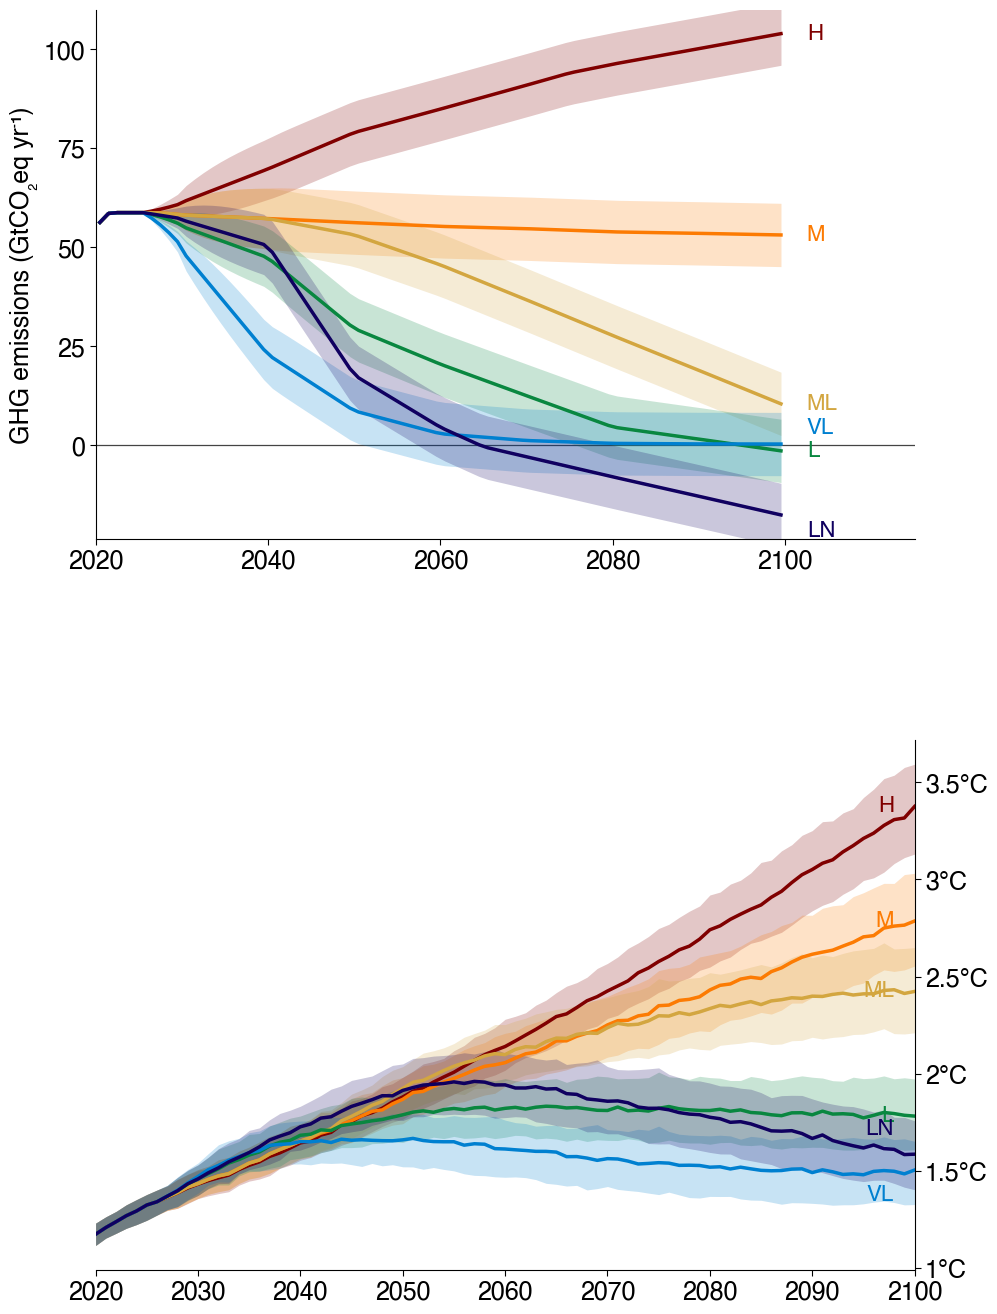

In [304]:
# ── STYLE ──────────────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':        'Helvetica',
    'font.size':          FS_YTICK,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.bottom': True,
    'axes.linewidth':     0.8,
    'xtick.major.size':   4,
    'ytick.major.size':   4,
    'xtick.major.width':  0.8,
    'ytick.major.width':  0.8,
    'axes.grid':          False,
})

# ── TIME ARRAYS & MASKS ────────────────────────────────────────────────────────
tp = f.timepoints
tb = f.timebounds

m_emis = (tp >= YEAR_START) & (tp <= YEAR_MAIN_END)
m_temp = (tb >= YEAR_START) & (tb <= YEAR_MAIN_END)

_XMAX_EMIS = YEAR_MAIN_END + LABEL_X_GAP + 12
_XMAX_TEMP = YEAR_MAIN_END

unc = np.tanh(
    (co2e.sel(scenario=NOHOS[0]) - co2e.sel(scenario=NOHOS[-1])) / 1e6 / 10
) * 8

# ── TIGHT Y LIMITS FROM DATA ───────────────────────────────────────────────────
def tight_ylim(arrays, pad=0.05):
    all_v = np.concatenate([np.asarray(a).ravel() for a in arrays])
    all_v = all_v[np.isfinite(all_v)]
    lo, hi = all_v.min(), all_v.max()
    margin = (hi - lo) * pad
    return lo - margin, hi + margin

emis_arrays, temp_lo_arrays, temp_hi_arrays = [], [], []
for scenario in NOHOS:
    emis_arrays.append(co2e.sel(scenario=scenario).values[m_emis] / 1e6)
    temp = (
        f.temperature.sel(scenario=scenario, layer=0) -
        _baseline.sel(scenario=scenario)
    )
    temp_lo_arrays.append(temp.quantile(0.33, dim='config').values[m_temp])
    temp_hi_arrays.append(temp.quantile(0.66, dim='config').values[m_temp])

ylim_emis = tight_ylim(emis_arrays)
ylim_temp = tight_ylim(temp_lo_arrays + temp_hi_arrays)

# ── BUILD FIGURE ───────────────────────────────────────────────────────────────
fig, (ax_e, ax_t) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
    gridspec_kw=dict(
        hspace=MARGIN['hspace'],
        top=MARGIN['top'], bottom=MARGIN['bottom'],
        left=MARGIN['left'], right=MARGIN['right'],
    ),
)
fig.patch.set_alpha(0)
ax_e.patch.set_alpha(0)
ax_t.patch.set_alpha(0)

# ── PANEL (a): GHG EMISSIONS ───────────────────────────────────────────────────
for scenario in NOHOS:
    color     = SCENARIO_COLORS[scenario]
    co2e_vals = co2e.sel(scenario=scenario).values / 1e6
    unc_vals  = unc.values

    ax_e.fill_between(
        tp[m_emis],
        co2e_vals[m_emis] - unc_vals[m_emis],
        co2e_vals[m_emis] + unc_vals[m_emis],
        color=color, lw=0, alpha=BAND_ALPHA,
    )
    ax_e.plot(tp[m_emis], co2e_vals[m_emis], color=color, lw=LINE_WIDTH)

    last_idx = np.flatnonzero(m_emis)[-1]
    ax_e.text(
        tp[last_idx] + LABEL_X_GAP,
        co2e_vals[last_idx] + LABEL_Y_OFFSETS_EMIS[scenario],
        SCENARIO_LABELS[scenario],
        color=color, fontsize=FS_LINE_LABEL, fontweight='bold',
        va='center', ha='left', clip_on=False,
    )

ax_e.axhline(0, color='#444444', lw=0.9, zorder=0)
ax_e.set_xlim(YEAR_START, _XMAX_EMIS)
ax_e.set_ylim(ylim_emis)
ax_e.set_ylabel('GHG emissions (GtCO₂eq yr⁻¹)', fontsize=FS_AXIS_LABEL)
ax_e.tick_params(axis='x', labelsize=FS_XTICK)
ax_e.tick_params(axis='y', labelsize=FS_YTICK)
ax_e.yaxis.set_major_locator(ticker.MultipleLocator(25))

# ── PANEL (b): TEMPERATURE — axis on the right ─────────────────────────────────
ax_t.spines['right'].set_visible(True)
ax_t.spines['left'].set_visible(False)
ax_t.yaxis.set_label_position('right')
ax_t.yaxis.tick_right()

for scenario in NOHOS:
    color = SCENARIO_COLORS[scenario]
    temp  = (
        f.temperature.sel(scenario=scenario, layer=0) -
        _baseline.sel(scenario=scenario)
    )
    q33 = temp.quantile(0.33, dim='config').values
    q50 = temp.median(dim='config').values
    q66 = temp.quantile(0.66, dim='config').values

    ax_t.fill_between(
        tb[m_temp], q33[m_temp], q66[m_temp],
        color=color, lw=0, alpha=BAND_ALPHA,
    )
    ax_t.plot(tb[m_temp], q50[m_temp], color=color, lw=LINE_WIDTH)

    last_idx = np.flatnonzero(m_temp)[-1]
    ax_t.text(
        tb[last_idx] - 2,
        q50[last_idx] + LABEL_Y_OFFSETS_TEMP[scenario],
        SCENARIO_LABELS[scenario],
        color=color, fontsize=FS_LINE_LABEL, fontweight='bold',
        va='center', ha='right', clip_on=True,
    )

ax_t.set_xlim(YEAR_START, _XMAX_TEMP)
ax_t.set_ylim(ylim_temp)
#ax_t.set_ylabel('Warming above 1850–1900 (°C)', fontsize=FS_AXIS_LABEL)
ax_t.tick_params(axis='x', labelsize=FS_XTICK)
ax_t.tick_params(axis='y', labelsize=FS_YTICK)
ax_t.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax_t.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:g}°C')
)

# ── SAVE + SHOW ────────────────────────────────────────────────────────────────
os.makedirs('../plots', exist_ok=True)
plt.savefig(OUTPUT_SVG, format='svg', bbox_inches='tight', transparent=True)
print(f'Saved: {OUTPUT_SVG}')
plt.show()

Saved: ../plots/infographic_figure_temp_only.svg


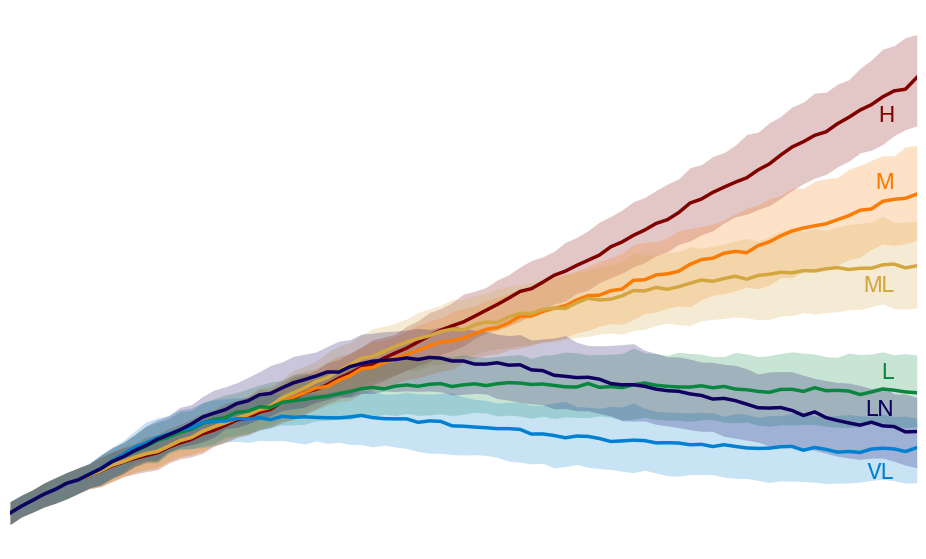

In [335]:
# ── PANEL B — STANDALONE (no axes, scenario names only) ────────────────────────
fig2, ax2 = plt.subplots(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN / 2))
fig2.patch.set_alpha(0)
ax2.patch.set_alpha(0)

# ╔══════════════════════════════════════════════════════════════════╗
# ║  TWEAK ME — label positions                                      ║
# ╠══════════════════════════════════════════════════════════════════╣
# x = year, y = °C above 1850–1900  |  set either to None to suppress
_LABEL_X_T = {
    'high-extension':    2098,
    'medium-extension':  2098,
    'medium-overshoot':  2098,
    'low':               2098,
    'verylow':           2098,
    'verylow-overshoot': 2098,
}
_LABEL_Y_T = {
    'high-extension':    3.18,
    'medium-extension':  2.84,
    'medium-overshoot':  2.32,
    'low':               1.88,
    'verylow':           1.37,
    'verylow-overshoot': 1.69,
}
# ╚══════════════════════════════════════════════════════════════════╝

for scenario in NOHOS:
    color = SCENARIO_COLORS[scenario]
    temp  = (
        f.temperature.sel(scenario=scenario, layer=0) -
        _baseline.sel(scenario=scenario)
    )
    q33 = temp.quantile(0.33, dim='config').values
    q50 = temp.median(dim='config').values
    q66 = temp.quantile(0.66, dim='config').values

    ax2.fill_between(
        tb[m_temp], q33[m_temp], q66[m_temp],
        color=color, lw=0, alpha=BAND_ALPHA,
    )
    ax2.plot(tb[m_temp], q50[m_temp], color=color, lw=LINE_WIDTH)

    lx = _LABEL_X_T.get(scenario)
    ly = _LABEL_Y_T.get(scenario)
    if lx is not None and ly is not None:
        ax2.text(
            lx, ly,
            SCENARIO_LABELS[scenario],
            color=color, fontsize=FS_LINE_LABEL, fontweight='bold',
            va='center', ha='right', clip_on=True,
        )

ax2.set_xlim(YEAR_START, _XMAX_TEMP)
ax2.set_ylim(ylim_temp)
ax2.axis('off')

_out2 = OUTPUT_SVG.replace('.svg', '_temp_only.svg')
plt.savefig(_out2, format='svg', bbox_inches='tight', transparent=True)
print(f'Saved: {_out2}')
plt.show()

Saved: ../plots/infographic_figure_emis_hist.svg


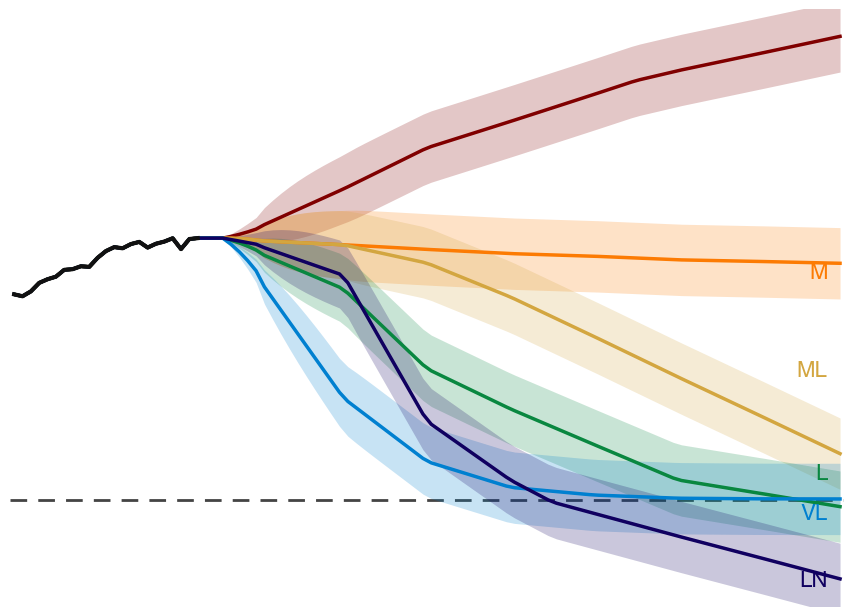

In [306]:
# ── PANEL A — STANDALONE with historical squiggle (no axes) ────────────────────
_HIST_END = 2022.5

m_full = (tp >= YEAR_HIST_START) & (tp <= YEAR_MAIN_END)
m_hist = (tp >= YEAR_HIST_START) & (tp <= _HIST_END)

# ── LABEL POSITIONS — set to None to suppress ─────────────────────────────────
# x = year (e.g. 2098), y = GtCO₂eq yr⁻¹ (absolute, not an offset)
_LABEL_X = {
    'high-extension':    None,   # suppressed
    'medium-extension':  2098,
    'medium-overshoot':  2098,
    'low':               2098,
    'verylow':           2098,
    'verylow-overshoot': 2098,
}
_LABEL_Y = {
    'high-extension':    None,   # suppressed
    'medium-extension':  51,
    'medium-overshoot':  29,
    'low':               6,
    'verylow':          -3,
    'verylow-overshoot':-18,
}
# ─────────────────────────────────────────────────────────────────────────────

_e_all = [co2e.sel(scenario=s).values[m_full] / 1e6 for s in NOHOS]
_v = np.concatenate(_e_all)
_v = _v[np.isfinite(_v)]
_pad = (_v.max() - _v.min()) * 0.05
_ylim_e = (_v.min() - _pad, _v.max() + _pad)

_W = FIG_WIDTH_IN * 0.92
fig4, ax4 = plt.subplots(figsize=(_W, _W * 0.72))
fig4.patch.set_alpha(0)
ax4.patch.set_alpha(0)

for scenario in NOHOS:
    color     = SCENARIO_COLORS[scenario]
    co2e_vals = co2e.sel(scenario=scenario).values / 1e6

    ax4.fill_between(
        tp[m_full],
        co2e_vals[m_full] - unc.values[m_full],
        co2e_vals[m_full] + unc.values[m_full],
        color=color, lw=0, alpha=BAND_ALPHA,
    )
    ax4.plot(tp[m_full], co2e_vals[m_full], color=color, lw=LINE_WIDTH)

    lx = _LABEL_X.get(scenario)
    ly = _LABEL_Y.get(scenario)
    if lx is not None and ly is not None:
        ax4.text(
            lx, ly,
            SCENARIO_LABELS[scenario],
            color=color, fontsize=FS_LINE_LABEL, fontweight='bold',
            va='center', ha='right', clip_on=True,
        )

hist_vals = co2e.sel(scenario=NOHOS[0]).values / 1e6
ax4.plot(tp[m_hist], hist_vals[m_hist], color='#111111', lw=LINE_WIDTH + 0.5, zorder=10)

ax4.axhline(0, color='#444444', lw=2.0, linestyle='--', dashes=(6, 4), zorder=0)
ax4.set_xlim(YEAR_HIST_START, YEAR_MAIN_END)
ax4.set_ylim(_ylim_e)
ax4.axis('off')

_out4 = OUTPUT_SVG.replace('.svg', '_emis_hist.svg')
os.makedirs('../plots', exist_ok=True)
plt.savefig(_out4, format='svg', bbox_inches='tight', transparent=True)
print(f'Saved: {_out4}')
plt.show()

Saved: ../plots/infographic_figure_emis_hist_nohi.svg


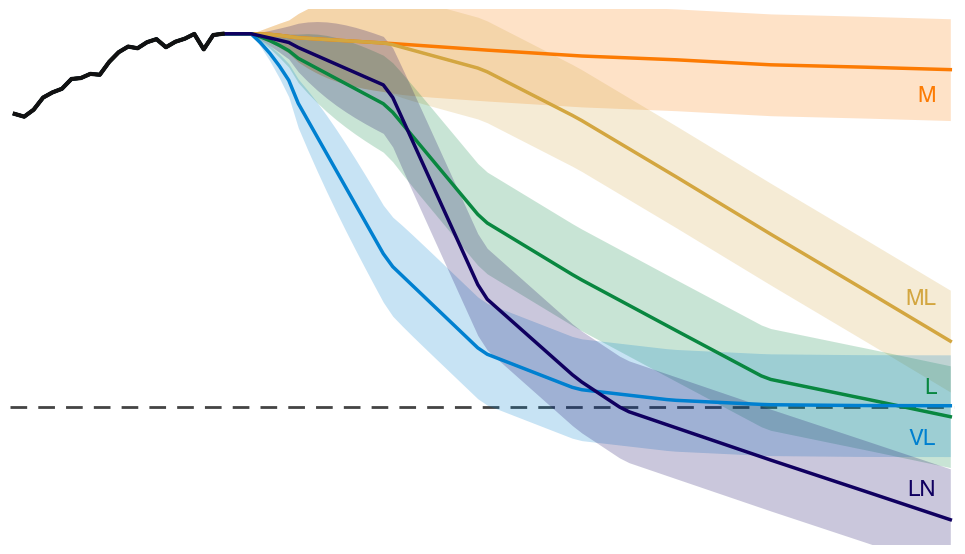

In [361]:
# ── PANEL A — STANDALONE, no high-extension scenario ───────────────────────────
_HIST_END = 2022.5
_NOHI = [s for s in NOHOS if s != 'high-extension']

m_full = (tp >= YEAR_HIST_START) & (tp <= YEAR_MAIN_END)
m_hist = (tp >= YEAR_HIST_START) & (tp <= _HIST_END)

# ╔══════════════════════════════════════════════════════════════════╗
# ║  TWEAK ME                                                        ║
# ╠══════════════════════════════════════════════════════════════════╣
_FIG_H = 5.34*1.3   # figure width  (inches)
_FIG_W = 9.38*1.3   # figure height (inches)

# x = year, y = GtCO₂eq yr⁻¹  |  set either to None to suppress label
_LABEL_X2 = {
    'medium-extension':  2098,
    'medium-overshoot':  2098,
    'low':               2098,
    'verylow':           2098,
    'verylow-overshoot': 2098,
}
_LABEL_Y2 = {
    'medium-extension':  49,
    'medium-overshoot':  17,
    'low':               3,
    'verylow':          -5,
    'verylow-overshoot':-13,
}
# ╚══════════════════════════════════════════════════════════════════╝

_e_all2 = [co2e.sel(scenario=s).values[m_full] / 1e6 for s in _NOHI]
_v2 = np.concatenate(_e_all2)
_v2 = _v2[np.isfinite(_v2)]
_pad2 = (_v2.max() - _v2.min()) * 0.05
_ylim_e2 = (_v2.min() - _pad2, _v2.max() + _pad2)

fig5, ax5 = plt.subplots(figsize=(_FIG_W, _FIG_H))
fig5.patch.set_alpha(0)
ax5.patch.set_alpha(0)

for scenario in _NOHI:
    color     = SCENARIO_COLORS[scenario]
    co2e_vals = co2e.sel(scenario=scenario).values / 1e6

    ax5.fill_between(
        tp[m_full],
        co2e_vals[m_full] - unc.values[m_full],
        co2e_vals[m_full] + unc.values[m_full],
        color=color, lw=0, alpha=BAND_ALPHA,
    )
    ax5.plot(tp[m_full], co2e_vals[m_full], color=color, lw=LINE_WIDTH)

    lx = _LABEL_X2.get(scenario)
    ly = _LABEL_Y2.get(scenario)
    if lx is not None and ly is not None:
        ax5.text(
            lx, ly,
            SCENARIO_LABELS[scenario],
            color=color, fontsize=FS_LINE_LABEL, fontweight='bold',
            va='center', ha='right', clip_on=True,
        )

hist_vals = co2e.sel(scenario=_NOHI[0]).values / 1e6
ax5.plot(tp[m_hist], hist_vals[m_hist], color='#111111', lw=LINE_WIDTH + 0.5, zorder=10)

ax5.axhline(0, color='#444444', lw=2.0, linestyle='--', dashes=(6, 4), zorder=0)
ax5.set_xlim(YEAR_HIST_START, YEAR_MAIN_END)
ax5.set_ylim(_ylim_e2)
ax5.axis('off')

_out5 = OUTPUT_SVG.replace('.svg', '_emis_hist_nohi.svg')
os.makedirs('../plots', exist_ok=True)
plt.savefig(_out5, format='svg', bbox_inches='tight', transparent=True)
print(f'Saved: {_out5}')
plt.show()

Saved: ../plots/infographic_figure_emis_hist_withhi.svg


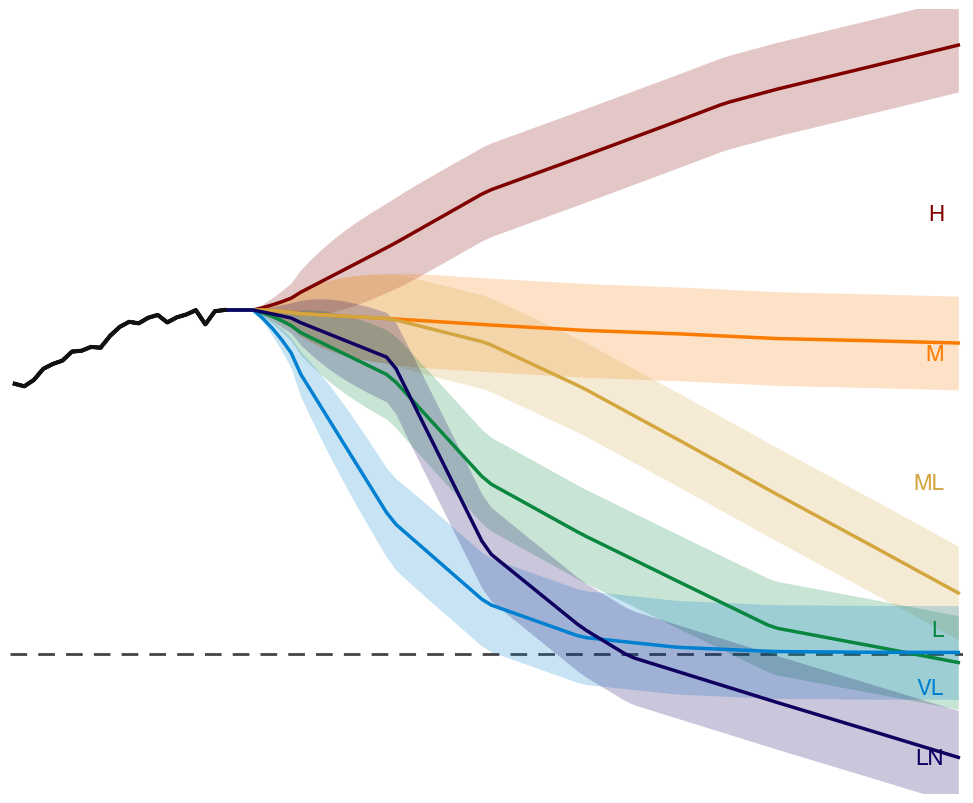

In [353]:
# ── PANEL A — STANDALONE, all scenarios including high-extension ────────────────
_HIST_END = 2022.5

m_full = (tp >= YEAR_HIST_START) & (tp <= YEAR_MAIN_END)
m_hist = (tp >= YEAR_HIST_START) & (tp <= _HIST_END)

# ╔══════════════════════════════════════════════════════════════════╗
# ║  TWEAK ME                                                        ║
# ╠══════════════════════════════════════════════════════════════════╣
_FIG_W = 9.46*1.3  # figure width  (inches)
_FIG_H = 5.05*1.55*1.3   # figure height (inches)

# x = year, y = GtCO₂eq yr⁻¹  |  set either to None to suppress label
_LABEL_X3 = {
    'high-extension':    2098,
    'medium-extension':  2098,
    'medium-overshoot':  2098,
    'low':               2098,
    'verylow':           2098,
    'verylow-overshoot': 2098,
}
_LABEL_Y3 = {
    'high-extension':    75,
    'medium-extension':  51,
    'medium-overshoot':  29,
    'low':               4,
    'verylow':          -6,
    'verylow-overshoot':-18,
}
# ╚══════════════════════════════════════════════════════════════════╝

_e_all3 = [co2e.sel(scenario=s).values[m_full] / 1e6 for s in NOHOS]
_v3 = np.concatenate(_e_all3)
_v3 = _v3[np.isfinite(_v3)]
_pad3 = (_v3.max() - _v3.min()) * 0.05
_ylim_e3 = (_v3.min() - _pad3, _v3.max() + _pad3)

fig6, ax6 = plt.subplots(figsize=(_FIG_W, _FIG_H))
fig6.patch.set_alpha(0)
ax6.patch.set_alpha(0)

for scenario in NOHOS:
    color     = SCENARIO_COLORS[scenario]
    co2e_vals = co2e.sel(scenario=scenario).values / 1e6

    ax6.fill_between(
        tp[m_full],
        co2e_vals[m_full] - unc.values[m_full],
        co2e_vals[m_full] + unc.values[m_full],
        color=color, lw=0, alpha=BAND_ALPHA,
    )
    ax6.plot(tp[m_full], co2e_vals[m_full], color=color, lw=LINE_WIDTH)

    lx = _LABEL_X3.get(scenario)
    ly = _LABEL_Y3.get(scenario)
    if lx is not None and ly is not None:
        ax6.text(
            lx, ly,
            SCENARIO_LABELS[scenario],
            color=color, fontsize=FS_LINE_LABEL, fontweight='bold',
            va='center', ha='right', clip_on=True,
        )

hist_vals = co2e.sel(scenario=NOHOS[0]).values / 1e6
ax6.plot(tp[m_hist], hist_vals[m_hist], color='#111111', lw=LINE_WIDTH + 0.5, zorder=10)

ax6.axhline(0, color='#444444', lw=2.0, linestyle='--', dashes=(6, 4), zorder=0)
ax6.set_xlim(YEAR_HIST_START, YEAR_MAIN_END)
ax6.set_ylim(_ylim_e3)
ax6.axis('off')

_out6 = OUTPUT_SVG.replace('.svg', '_emis_hist_withhi.svg')
os.makedirs('../plots', exist_ok=True)
plt.savefig(_out6, format='svg', bbox_inches='tight', transparent=True)
print(f'Saved: {_out6}')
plt.show()

In [309]:
print("Median warming by 2100 (°C above 1850–1900)\n")

for scenario in NOHOS:
    temp_2100 = (
        f.temperature.sel(scenario=scenario, layer=0, timebounds=2100) -
        _baseline.sel(scenario=scenario)
    ).median(dim='config').item()
    print(f"  {SCENARIO_LABELS[scenario]:<30}  {temp_2100:.2f} °C")

Median warming by 2100 (°C above 1850–1900)

  H                               3.38 °C
  M                               2.79 °C
  ML                              2.42 °C
  L                               1.78 °C
  VL                              1.50 °C
  LN                              1.58 °C
